# Level 1 - Task 2 & 3: Exploratory Data Analysis (EDA) & Basic Data Visualization
**Dataset:** Iris Dataset  
**Tools:** Python, Pandas, Matplotlib, Seaborn

**Objective:** Identifying patterns, trends, and summary statistics, also visualizing the distribution and relationships within the dataset to extract actionable insights.

In [1]:
# ============================
# 1. Import Libraries
# ============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# ============================
# 2. Create Output Folders
# ============================
import os

base_path = '/workspaces/codveda_technologies-data_analysis_internship'
os.makedirs(f'{base_path}/visualizations/eda', exist_ok=True)

print(" Output folders created successfully!")

 Output folders created successfully!


In [3]:
# ============================
# 3. Load the Dataset
# ============================
df = pd.read_csv('/workspaces/codveda_technologies-data_analysis_internship/data/raw/1) iris.csv')

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

print("\nDataset Info:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (150, 5)

First 5 rows:


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa



Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 7.2 KB

Missing Values:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64


In [4]:
# ============================
# 4. Summary Statistics
# ============================
print("=== SUMMARY STATISTICS ===")
display(df.describe())

print("\n=== Species Distribution ===")
print(df['species'].value_counts())

print("\n" + "="*60)
print("INITIAL INSIGHTS:")
print("="*60)
print("""
• The dataset is perfectly balanced (50 samples per species).
• No missing values detected.
• Petal measurements show higher variation than sepal measurements.
• Mean petal length (3.76) and width (1.20) have wider ranges than sepal features.
""")

=== SUMMARY STATISTICS ===


,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000



=== Species Distribution ===
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

INITIAL INSIGHTS:

• The dataset is perfectly balanced (50 samples per species).
• No missing values detected.
• Petal measurements show higher variation than sepal measurements.
• Mean petal length (3.76) and width (1.20) have wider ranges than sepal features.



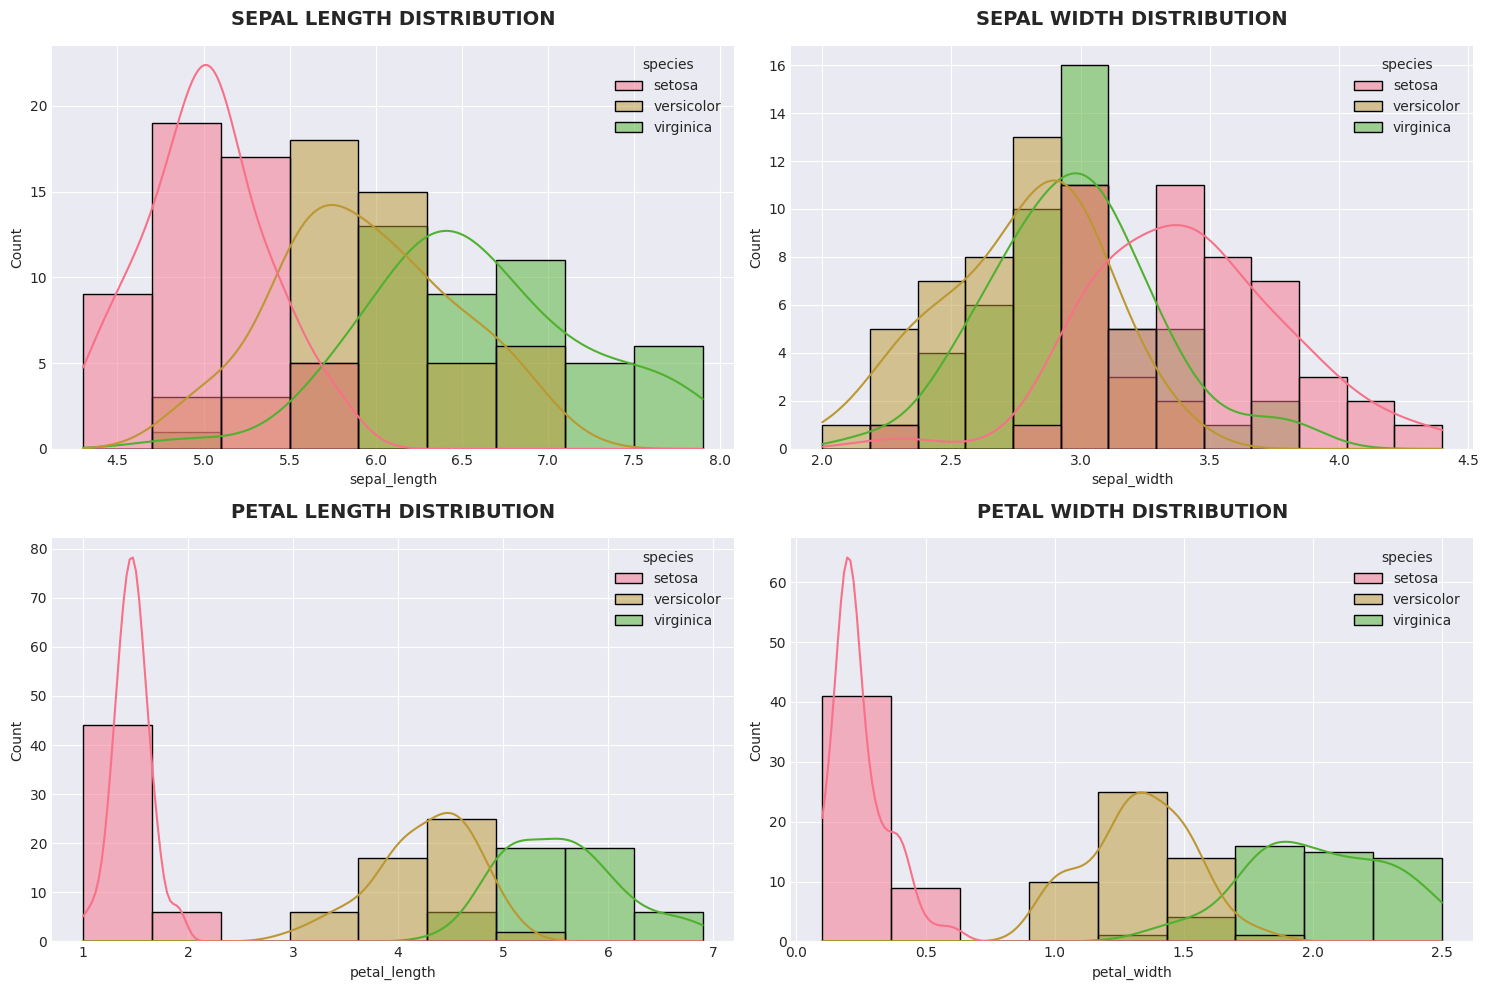


HISTOGRAM INSIGHTS:

• Setosa has distinctly smaller petal length and width.
• Versicolor and Virginica overlap in sepal features but are separable by petal features.
• Petal length shows bimodal distribution overall due to species differences.



In [5]:
# ============================
# 5. Univariate Analysis - Histograms
# ============================
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

sns.histplot(data=df, x='sepal_length', kde=True, hue='species', ax=axes[0,0])
axes[0,0].set_title('SEPAL LENGTH DISTRIBUTION', fontsize=14, fontweight='bold', pad=15)

sns.histplot(data=df, x='sepal_width', kde=True, hue='species', ax=axes[0,1])
axes[0,1].set_title('SEPAL WIDTH DISTRIBUTION', fontsize=14, fontweight='bold', pad=15)

sns.histplot(data=df, x='petal_length', kde=True, hue='species', ax=axes[1,0])
axes[1,0].set_title('PETAL LENGTH DISTRIBUTION', fontsize=14, fontweight='bold', pad=15)

sns.histplot(data=df, x='petal_width', kde=True, hue='species', ax=axes[1,1])
axes[1,1].set_title('PETAL WIDTH DISTRIBUTION', fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
os.makedirs('../../visualizations', exist_ok=True)
plt.savefig('../../visualizations/iris_histograms.png', dpi=300, bbox_inches='tight')
plt.show()

# ==================== INSIGHTS ====================
print("\n" + "="*60)
print("HISTOGRAM INSIGHTS:")
print("="*60)
print("""
• Setosa has distinctly smaller petal length and width.
• Versicolor and Virginica overlap in sepal features but are separable by petal features.
• Petal length shows bimodal distribution overall due to species differences.
""")

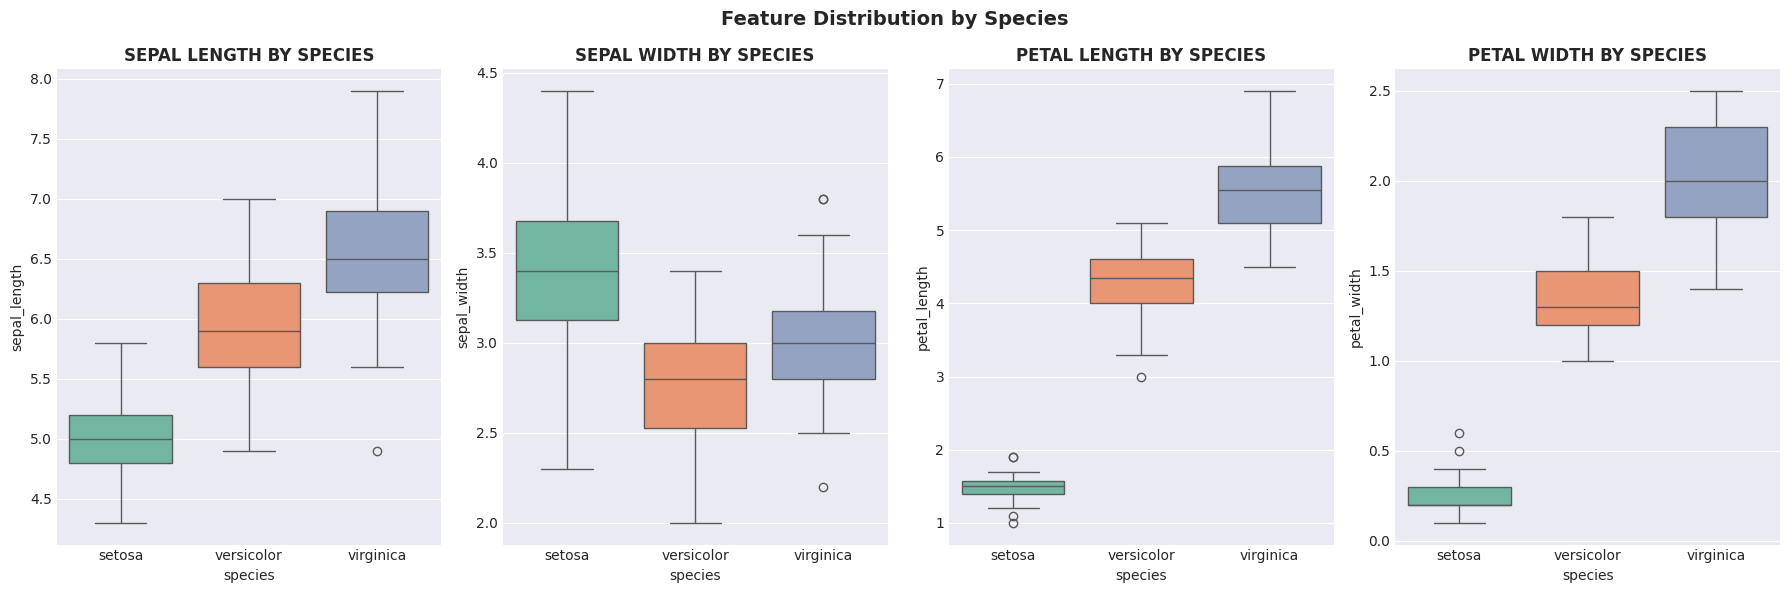


BOXPLOT INSIGHTS:

• Setosa is the most compact cluster with smallest petals and fewest outliers.
• Virginica has the largest petals on average.
• Sepal width has more overlap between species compared to other features.



In [7]:
# ============================
# 6. Boxplots
# ============================
fig, axes = plt.subplots(1, 4, figsize=(18, 6))
features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

for i, col in enumerate(features):
    sns.boxplot(data=df, x='species', y=col, palette='Set2', ax=axes[i])
    axes[i].set_title(f'{col.replace("_", " ").upper()} BY SPECIES', fontsize=12, fontweight='bold')


plt.suptitle('Feature Distribution by Species', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../../visualizations/iris_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*60)
print("BOXPLOT INSIGHTS:")
print("="*60)
print("""
• Setosa is the most compact cluster with smallest petals and fewest outliers.
• Virginica has the largest petals on average.
• Sepal width has more overlap between species compared to other features.
""")

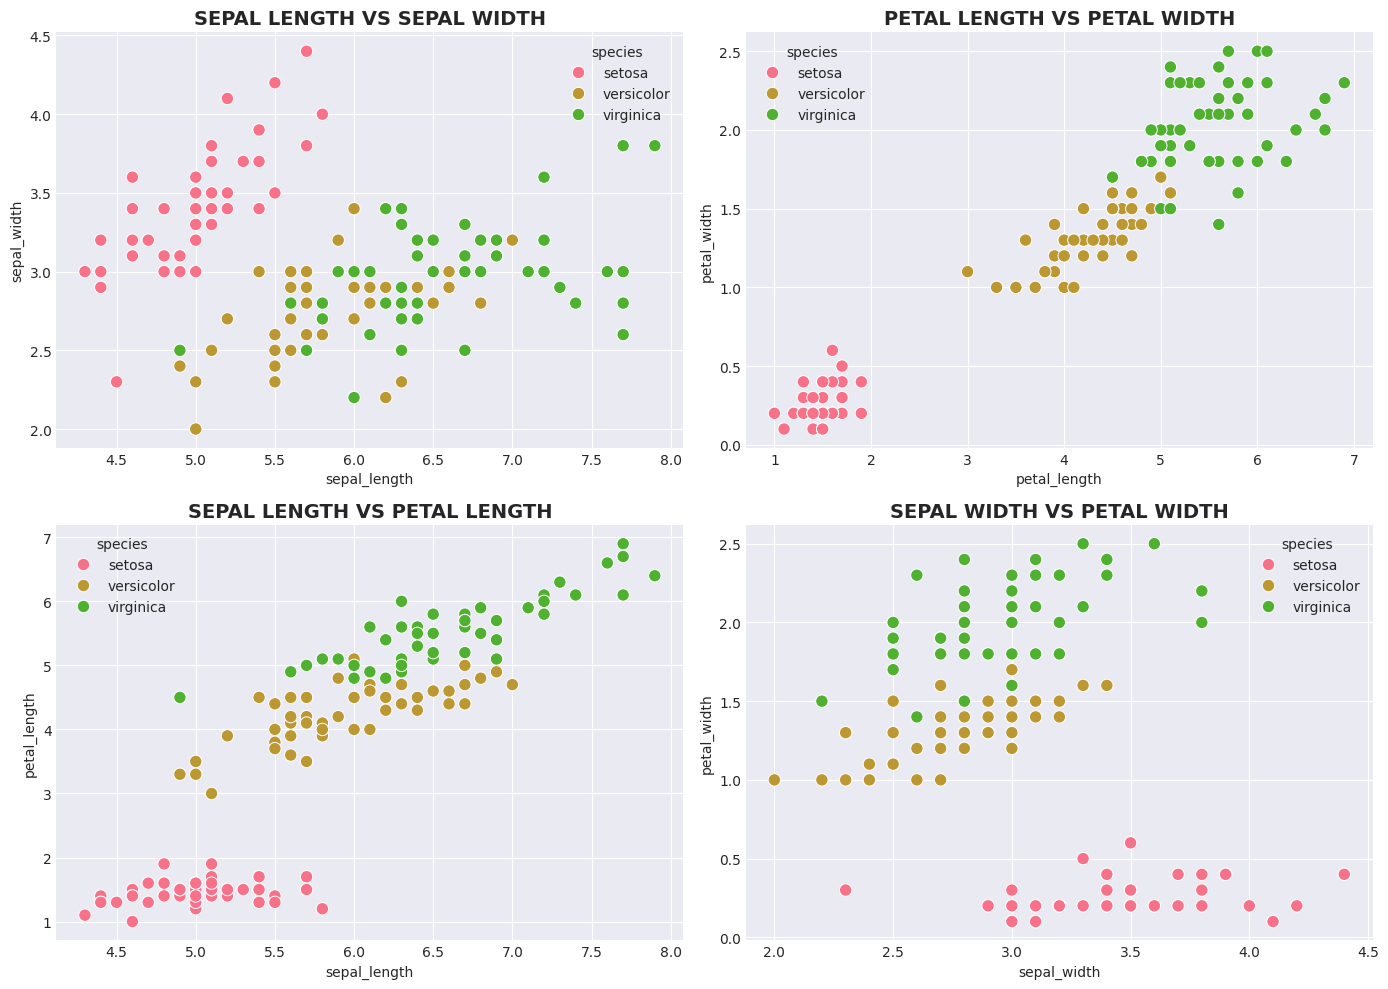


SCATTER PLOT INSIGHTS:

• Strongest linear relationship exists between petal length and petal width (almost perfect separation).
• Setosa forms a very distinct cluster in all plots.
• Petal features are superior for distinguishing species compared to sepal features.



In [ ]:
# ============================
# 7. Bivariate Analysis - Scatter Plots
# ============================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.scatterplot(data=df, x='sepal_length', y='sepal_width', hue='species', ax=axes[0,0], s=80)
axes[0,0].set_title('SEPAL LENGTH VS SEPAL WIDTH', fontsize=14, fontweight='bold')

sns.scatterplot(data=df, x='petal_length', y='petal_width', hue='species', ax=axes[0,1], s=80)
axes[0,1].set_title('PETAL LENGTH VS PETAL WIDTH', fontsize=14, fontweight='bold')

sns.scatterplot(data=df, x='sepal_length', y='petal_length', hue='species', ax=axes[1,0], s=80)
axes[1,0].set_title('SEPAL LENGTH VS PETAL LENGTH', fontsize=14, fontweight='bold')

sns.scatterplot(data=df, x='sepal_width', y='petal_width', hue='species', ax=axes[1,1], s=80)
axes[1,1].set_title('SEPAL WIDTH VS PETAL WIDTH', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../../visualizations/iris_scatter_plots.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*60)
print("SCATTER PLOT INSIGHTS:")
print("="*60)
print("""
• Strongest linear relationship exists between petal length and petal width (almost perfect separation).
• Setosa forms a very distinct cluster in all plots.
• Petal features are superior for distinguishing species compared to sepal features.
""")

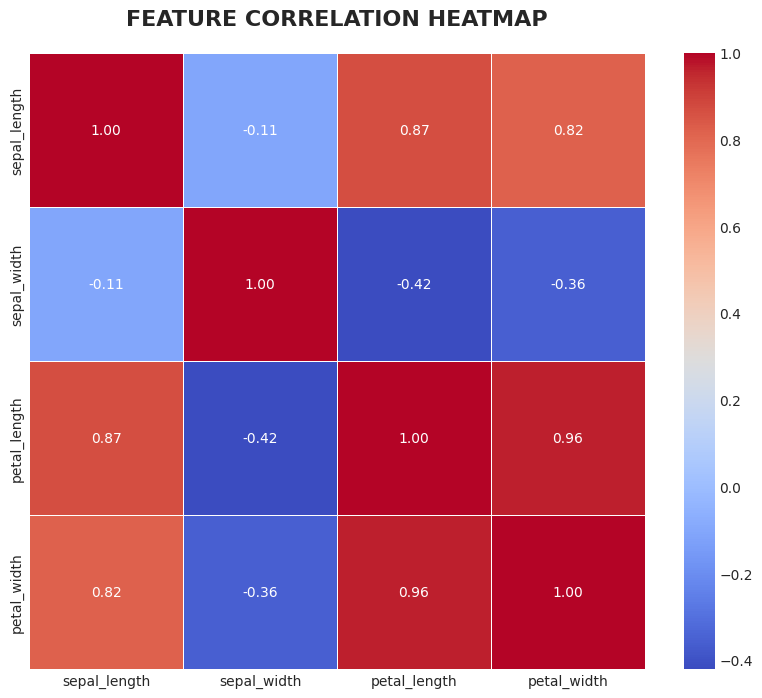


Strongest Positive Correlations:
petal_length    1.000000
petal_width     0.962757
sepal_length    0.871754
sepal_width    -0.420516
Name: petal_length, dtype: float64


In [ ]:
# ============================
# 8. Correlation Heatmap
# ============================
plt.figure(figsize=(10, 8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm', linewidths=0.5, fmt='.2f', square=True)
plt.title('FEATURE CORRELATION HEATMAP', fontsize=16, fontweight='bold', pad=20)
plt.savefig('../../visualizations/iris_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nStrongest Positive Correlations:")
print(corr['petal_length'].sort_values(ascending=False))

In [9]:
# ============================
# 9. Final Summary & Key Business/Scientific Insights
# ============================
print("\n" + "="*70)
print("FINAL PROJECT INSIGHTS & CONCLUSIONS")
print("="*70)
print("""
1. Petal length and petal width are the most strongly correlated features (r > 0.96), making them the most discriminating for species classification.
   - Setosa is clearly separable from Versicolor and Virginica across all features.
   - Sepal width shows the weakest correlation with other features and the highest overlap between species.
   - Distribution plots confirm that petal measurements follow near-normal distributions within each species group.
2. Species Characteristics:
   - Setosa: Smallest petals
   - Versicolor: Medium petals
   - Virginica: Largest petals

EDA and Visualization completed succcessfully.
""")
print("="*70)


FINAL PROJECT INSIGHTS & CONCLUSIONS

1. Petal length and petal width are the most strongly correlated features (r > 0.96), making them the most discriminating for species classification.
   - Setosa is clearly separable from Versicolor and Virginica across all features.
   - Sepal width shows the weakest correlation with other features and the highest overlap between species.
   - Distribution plots confirm that petal measurements follow near-normal distributions within each species group.
2. Species Characteristics:
   - Setosa: Smallest petals
   - Versicolor: Medium petals
   - Virginica: Largest petals

EDA and Visualization completed succcessfully.

